In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

In [4]:
weights = [1, 2, 5, 10, 100]
weight_to_data = {
    weight: pd.read_csv(f"../runs/antibiotics_weight_{weight}/staged_learning_1.csv")
    for weight in weights
}

for weight, data in weight_to_data.items():
    print(f"Weight: {weight}")
    print(f"Number generated: {len(data):,}")
    print(f"Number invalid = {len(data[data['SMILES_state'] == 0]):,}")
    generated = data[data["SMILES_state"] == 1]
    print(f"Number generated after filtering invalid: {len(generated):,}")
    print()

Weight: 1
Number generated: 10,000
Number invalid = 135
Number generated after filtering invalid: 9,865

Weight: 2
Number generated: 10,000
Number invalid = 130
Number generated after filtering invalid: 9,870

Weight: 5
Number generated: 10,000
Number invalid = 160
Number generated after filtering invalid: 9,840

Weight: 10
Number generated: 10,000
Number invalid = 186
Number generated after filtering invalid: 9,814

Weight: 100
Number generated: 10,000
Number invalid = 271
Number generated after filtering invalid: 9,729



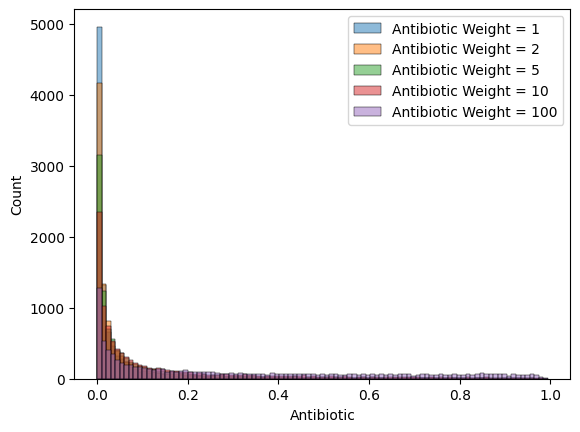

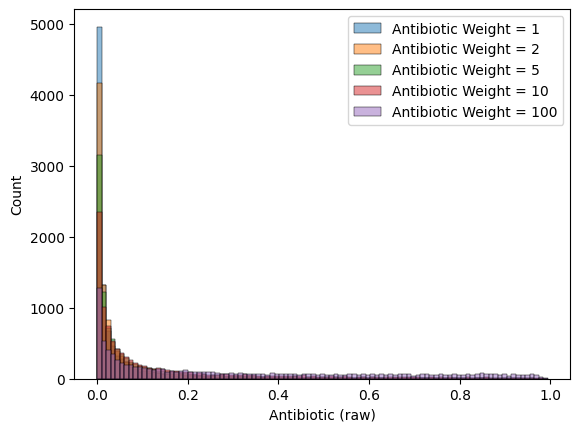

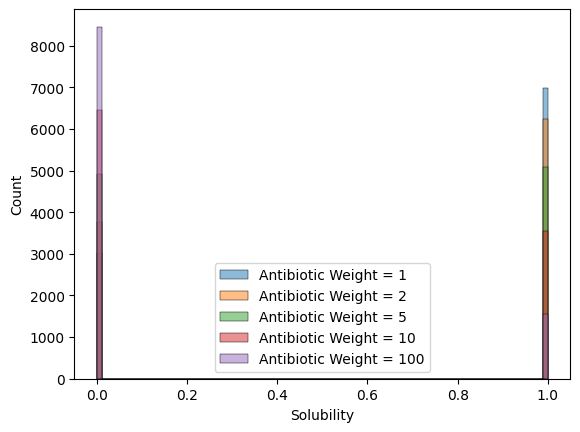

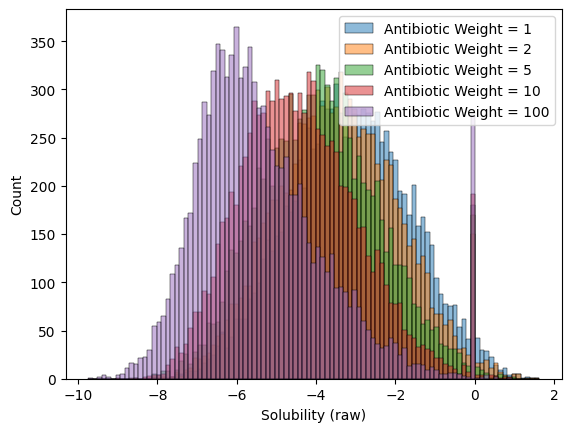

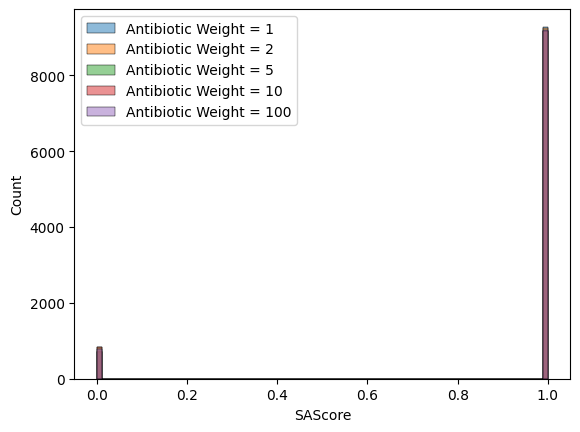

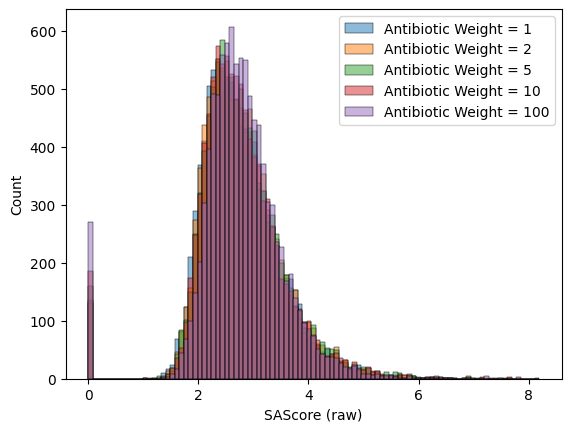

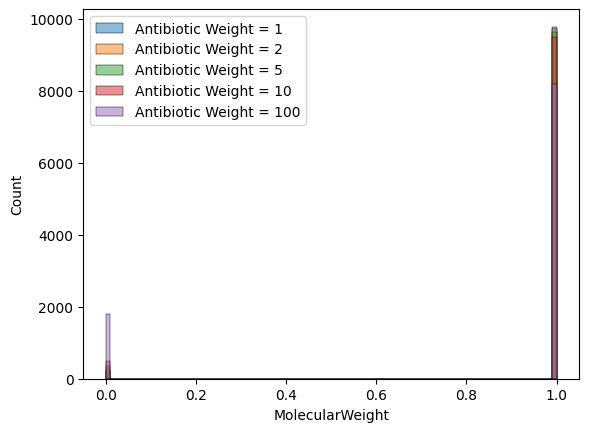

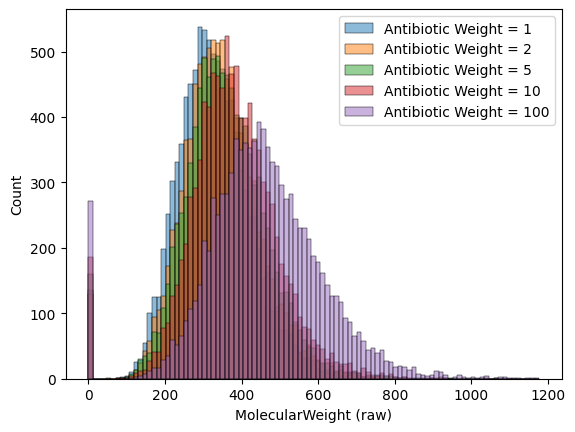

In [7]:
for prop in ["Antibiotic", "Solubility", "SAScore", "MolecularWeight"]:
    for suffix in ["", " (raw)"]:
        prop_name = prop + suffix

        min_val = min([weight_to_data[weight][prop_name].min() for weight in weights])
        max_val = max([weight_to_data[weight][prop_name].max() for weight in weights])
        bins = np.linspace(min_val, max_val, 100)

        for weight, data in weight_to_data.items():
            sns.histplot(data[prop_name], bins=bins, label=f"Antibiotic Weight = {weight}", alpha=0.5)
        plt.legend()
        plt.show()

In [16]:
weight_to_image = {}

for weight, data in weight_to_data.items():
    hits = data.query("`Antibiotic (raw)` >= 0.5 & `Solubility (raw)` >= -4 & `SAScore (raw)` <= 4 & `MolecularWeight (raw)` <= 600")
    print(f"Number of hits for weight {weight} = {len(hits):,}")
    num_to_display = min(20, len(hits))
    mols = [Chem.MolFromSmiles(smiles) for smiles in hits["SMILES"].sample(n=num_to_display, replace=False, random_state=0)]
    weight_to_image[weight] = Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(300, 300),
    )

Number of hits for weight 1 = 49
Number of hits for weight 2 = 48
Number of hits for weight 5 = 71
Number of hits for weight 10 = 59
Number of hits for weight 100 = 19


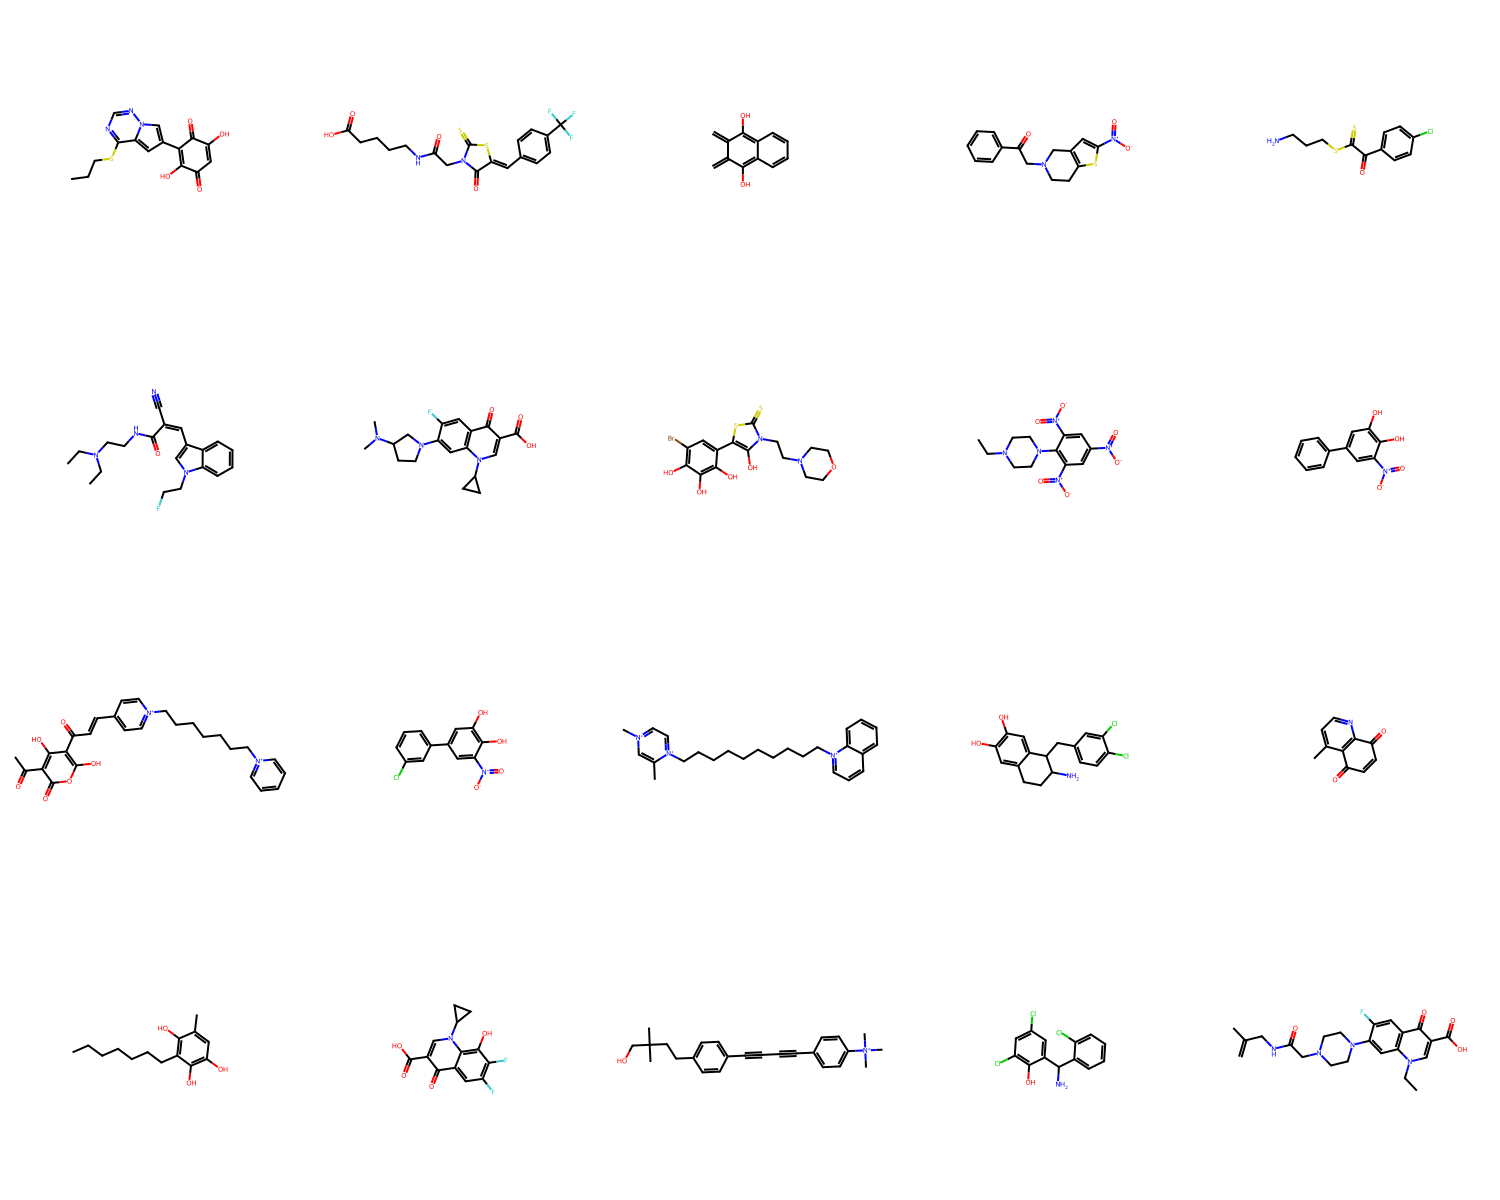

In [15]:
weight_to_image[5]